In [1]:
 # Goal:
# Transform clean disaster declaration, public assistance, and disaster summary
# datasets into modelling-ready features for disaster recovery cost prediction.
#
# Final output:
# features_terranova.csv

### STEP 1 -  import libraries

In [2]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

# Define path
DATA_PROCESSED = os.path.join("..", "data", "processed")



In [3]:
# step 1b: Load Clean Datasets

declarations = pd.read_csv(
    os.path.join(DATA_PROCESSED, "declarations_clean.csv"),
    parse_dates=["declarationdate", "incidentbegindate", "incidentenddate"]
)

public_assistance = pd.read_csv(
    os.path.join(DATA_PROCESSED, "public_assistance_clean.csv")
)

disaster_summaries = pd.read_csv(
    os.path.join(DATA_PROCESSED, "disaster_summaries_clean.csv"),
    parse_dates=["paloaddate", "ialoaddate"]
)

print("Declarations:", declarations.shape)
print("Public Assistance:", public_assistance.shape)
print("Disaster Summaries:", disaster_summaries.shape)

Declarations: (69877, 10)
Public Assistance: (812858, 8)
Disaster Summaries: (3945, 11)


In [4]:
print(declarations.dtypes)
declarations.head()

disasternumber                       int64
state                               object
declarationtype                     object
incidenttype                        object
declarationdate             datetime64[ns]
incidentbegindate           datetime64[ns]
incidentenddate             datetime64[ns]
fydeclared                           int64
designatedarea                      object
declarationrequestnumber             int64
dtype: object


,disasternumber,state,declarationtype,incidenttype,declarationdate,incidentbegindate,incidentenddate,fydeclared,designatedarea,declarationrequestnumber
0,3610,PR,EM,Severe Storm,2024-08-13,2024-08-13,2024-08-16,2024,Adjuntas (Municipio),24124
1,5529,OR,FM,Fire,2024-08-09,2024-08-08,NaT,2024,Washington (County),24122
2,5528,OR,FM,Fire,2024-08-06,2024-08-04,NaT,2024,Jefferson (County),24116
3,5527,OR,FM,Fire,2024-08-02,2024-08-02,NaT,2024,Deschutes (County),24111
4,3610,PR,EM,Severe Storm,2024-08-13,2024-08-13,2024-08-16,2024,Aguada (Municipio),24124


### STEP 2 - Engineered Some Declaration Features

In [5]:
# step 2a:  Engineer Declaration Features

declarations = declarations.copy()

# Disaster duration:
# How long the disaster lasted.

declarations["disaster_duration_days"] = (
    declarations["incidentenddate"] - declarations["incidentbegindate"]
).dt.days

# step 2b: Declaration delay:
# How long it took for the disaster to be officially declared.

declarations["declaration_delay_days"] = (
    declarations["declarationdate"] - declarations["incidentbegindate"]
).dt.days

# step 2c: Clean negative values.
# Negative duration or delay is not meaningful for this project.

declarations["disaster_duration_days"] = declarations["disaster_duration_days"].clip(lower=0)
declarations["declaration_delay_days"] = declarations["declaration_delay_days"].clip(lower=0)

# step 2d: Fill missing duration values with 0.
# Some events may not have an incident end date.

declarations["disaster_duration_days"] = declarations["disaster_duration_days"].fillna(0)
declarations["declaration_delay_days"] = declarations["declaration_delay_days"].fillna(0)

In [6]:
# step 2e: Engineer Date and Seasonality Features

declarations["declaration_year"] = declarations["declarationdate"].dt.year
declarations["declaration_month"] = declarations["declarationdate"].dt.month
declarations["declaration_quarter"] = declarations["declarationdate"].dt.quarter


def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


declarations["declaration_season"] = declarations["declaration_month"].apply(get_season)

declarations[
    [
        "declaration_year",
        "declaration_month",
        "declaration_quarter",
        "declaration_season"
    ]
].head()

,declaration_year,declaration_month,declaration_quarter,declaration_season
0,2024,8,3,Summer
1,2024,8,3,Summer
2,2024,8,3,Summer
3,2024,8,3,Summer
4,2024,8,3,Summer


In [7]:
# step 2f: Engineer Declaration Frequency Features

# Number of declarations in each fiscal year.

declarations["fy_declaration_count"] = (
    declarations.groupby("fydeclared")["disasternumber"]
    .transform("count")
)

# step 2g: Total declarations per state.

declarations["state_declaration_count"] = (
    declarations.groupby("state")["disasternumber"]
    .transform("count")
)

# step 2h: Frequency of each incident type.

declarations["incident_frequency"] = (
    declarations.groupby("incidenttype")["disasternumber"]
    .transform("count")
)

# step 2i: Number of declarations for each state and incident type.

declarations["state_incident_count"] = (
    declarations.groupby(["state", "incidenttype"])["disasternumber"]
    .transform("count")
)

# step 2j: Number of declarations for each state and fiscal year.

declarations["state_year_count"] = (
    declarations.groupby(["state", "fydeclared"])["disasternumber"]
    .transform("count")
)

In [8]:
# step 2k: Aggregate Declaration Features by Disaster Number

declaration_agg_features = (
    declarations.groupby("disasternumber")
    .agg(
        avg_duration_days=("disaster_duration_days", "mean"),
        avg_delay_days=("declaration_delay_days", "mean")
    )
    .round(2)
    .reset_index()
)

declaration_agg_features.head()

,disasternumber,avg_duration_days,avg_delay_days
0,1,0.0,0.0
1,2,0.0,0.0
2,3,0.0,0.0
3,4,0.0,0.0
4,5,0.0,0.0


In [9]:
# step 2l: Remove Raw Date Columns

declarations.drop(
    columns=[
        "declarationdate",
        "incidentbegindate",
        "incidentenddate"
    ],
    inplace=True
)

In [10]:
# step 2m: Create Final Declaration Feature Table

declaration_features = declarations.merge(
    declaration_agg_features,
    how="left",
    on="disasternumber"
)

declaration_features = declaration_features.drop_duplicates(
    subset=["disasternumber"]
)

print(declaration_features.shape)
declaration_features.head()

(5184, 20)


,disasternumber,state,declarationtype,incidenttype,fydeclared,designatedarea,declarationrequestnumber,disaster_duration_days,declaration_delay_days,declaration_year,declaration_month,declaration_quarter,declaration_season,fy_declaration_count,state_declaration_count,incident_frequency,state_incident_count,state_year_count,avg_duration_days,avg_delay_days
0,3610,PR,EM,Severe Storm,2024,Adjuntas (Municipio),24124,3.0,0,2024,8,3,Summer,2147,2116,19308,380,91,3.0,0.0
1,5529,OR,FM,Fire,2024,Washington (County),24122,0.0,1,2024,8,3,Summer,2147,646,3876,180,33,0.0,1.0
2,5528,OR,FM,Fire,2024,Jefferson (County),24116,0.0,2,2024,8,3,Summer,2147,646,3876,180,33,0.0,2.0
3,5527,OR,FM,Fire,2024,Deschutes (County),24111,0.0,0,2024,8,3,Summer,2147,646,3876,180,33,0.0,0.0
6,4312,CA,DR,Severe Storm,2017,Resighini Rancheria (Indian Reservation),17035,3.0,83,2017,5,2,Spring,1835,1689,19308,384,115,3.0,83.0


### Step 3 Engineer Public Assistance Features

In [11]:
print(public_assistance.dtypes)
public_assistance.head()


disasternumber             int64
stateabbreviation         object
projectamount            float64
federalshareobligated    float64
totalobligated           float64
projectsize               object
damagecategorycode        object
applicationtitle          object
dtype: object


,disasternumber,stateabbreviation,projectamount,federalshareobligated,totalobligated,projectsize,damagecategorycode,applicationtitle
0,1361,WA,1203.00,902.25,957.10,Small,B,(PW# 81) INSPECTION OF TOWN BUILDINGS & UTILITIES
1,1603,LA,15156787.07,15156787.07,15312129.35,Large,E,(PW# 18773) CONTENTS ROLLUP-MULTIPLE SITES; MU...
2,3582,MS,159127.24,119345.43,119345.43,Small,B,MS- State Department of Health EPM-Period 1 - ...
3,1817,WA,6847.49,5135.62,5135.62,Small,C,(PW# 537) SEBC005 - S. Emery Ave. Road/Shoulde...
4,3582,MS,118703.32,89027.49,89027.49,Small,B,MS- State Department of Health EPM-Period 3 - ...


In [12]:
# Step 3a: Public Assistance Feature Engineering

pa_features = (
    public_assistance.groupby("disasternumber")
    .agg(
        # Step 3b - Project amount
        pa_project_count=("projectamount", "count"),
        pa_project_amount_total=("projectamount", "sum"),
        pa_project_amount_mean=("projectamount", "mean"),

        # Step 3c - Federal share obligated
        pa_obligated_total=("federalshareobligated", "sum"),
        pa_obligated_mean=("federalshareobligated", "mean"),
        pa_obligated_max=("federalshareobligated", "max"),
    )
    .reset_index()
)


In [13]:
# Engineer Project Size Features

# Step 3d - Project size thresholds
large_threshold = public_assistance["projectamount"].quantile(0.75)
small_threshold = public_assistance["projectamount"].quantile(0.25)

pa_features["large_project_count"] = (
    public_assistance[public_assistance["projectamount"] >= large_threshold]
    .groupby("disasternumber")
    .size()
    .reindex(pa_features["disasternumber"])
    .fillna(0)
    .values
)

pa_features["small_project_count"] = (
    public_assistance[public_assistance["projectamount"] <= small_threshold]
    .groupby("disasternumber")
    .size()
    .reindex(pa_features["disasternumber"])
    .fillna(0)
    .values
)



In [14]:
# Step 3e: Ratio and interaction features
pa_features["avg_obligation_per_project"] = (
    pa_features["pa_obligated_total"] / (pa_features["pa_project_count"] + 1)
)

pa_features["funding_intensity"] = (
    pa_features["pa_obligated_total"] / (pa_features["pa_project_amount_total"] + 1)
)

pa_features["large_project_ratio"] = (
    pa_features["large_project_count"] / (pa_features["pa_project_count"] + 1)
)

pa_features["small_project_ratio"] = (
    pa_features["small_project_count"] / (pa_features["pa_project_count"] + 1)
)

pa_features = pa_features.fillna(0)

pa_features.head()

,disasternumber,pa_project_count,pa_project_amount_total,pa_project_amount_mean,pa_obligated_total,pa_obligated_mean,pa_obligated_max,large_project_count,small_project_count,avg_obligation_per_project,funding_intensity,large_project_ratio,small_project_ratio
0,1239,276,10600492.88,38407.582899,7950369.84,28805.687826,1309005.45,34.0,67.0,28701.696173,0.750000,0.122744,0.241877
1,1257,1760,42972184.44,24416.013886,32229051.37,18311.961006,804284.00,118.0,634.0,18301.562391,0.749998,0.067007,0.360023
2,1260,212,12948267.66,61076.734245,9711200.82,45807.551038,687414.68,39.0,60.0,45592.492113,0.750000,0.183099,0.281690
3,1261,138,7331674.17,53128.073696,5498755.69,39846.055725,772826.25,30.0,48.0,39559.393453,0.750000,0.215827,0.345324
4,1262,268,19964936.88,74496.033134,14973702.82,55872.025448,3104475.92,56.0,89.0,55664.322751,0.750000,0.208178,0.330855


In [15]:
# step 3f: Create Target Table

# The modelling target is total disaster recovery cost.
# We aggregate total obligated cost by disaster number.

cost_target = (
    public_assistance.groupby("disasternumber", as_index=False)
    .agg(
        totalobligated=("totalobligated", "sum")
    )
)

# Log-transform the target to reduce skewness.

cost_target["log_totalobligated"] = np.log1p(cost_target["totalobligated"])

cost_target.head()

,disasternumber,totalobligated,log_totalobligated
0,1239,8224551.92,15.922634
1,1257,33271088.84,17.320199
2,1260,10096131.65,16.127663
3,1261,5735788.22,15.562236
4,1262,15408228.37,16.550412


### step 5 - Engineer Disaster Summaries Features

In [16]:
print(disaster_summaries.dtypes)
disaster_summaries.head()

disasternumber                         int64
totalnumberiaapproved                float64
totalamountihpapproved               float64
totalamounthaapproved                float64
totalamountonaapproved               float64
totalobligatedamountpa               float64
totalobligatedamountcatab            float64
totalobligatedamountcatc2g           float64
totalobligatedamounthmgp             float64
paloaddate                    datetime64[ns]
ialoaddate                    datetime64[ns]
dtype: object


,disasternumber,totalnumberiaapproved,totalamountihpapproved,totalamounthaapproved,totalamountonaapproved,totalobligatedamountpa,totalobligatedamountcatab,totalobligatedamountcatc2g,totalobligatedamounthmgp,paloaddate,ialoaddate
0,3601,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaT,NaT
1,3602,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaT,NaT
2,1802,0.0,0.0,0.0,0.0,1.881275e+07,1.342309e+07,4.869890e+06,2710679.0,2026-02-06,NaT
3,1292,0.0,0.0,0.0,0.0,2.981058e+08,1.436027e+08,1.504852e+08,67665966.0,2026-02-06,NaT
4,3163,0.0,0.0,0.0,0.0,5.380816e+06,5.369404e+06,0.000000e+00,0.0,2026-02-06,NaT


In [17]:
# step 4a: Engineer Disaster Summary Features

ds_features = (
    disaster_summaries.groupby("disasternumber")
    .agg(
        ia_approved_count=("totalnumberiaapproved", "sum"),
        ihp_amount=("totalamountihpapproved", "sum"),
        ona_amount=("totalamountonaapproved", "sum"),
        pa_amount=("totalobligatedamountpa", "sum")
    )
    .reset_index()
)

ds_features.head()

,disasternumber,ia_approved_count,ihp_amount,ona_amount,pa_amount
0,1239,0.0,0.0,0.0,8225378.98
1,1240,0.0,0.0,0.0,25149994.52
2,1241,0.0,0.0,0.0,0.00
3,1242,0.0,0.0,0.0,12713027.57
4,1243,0.0,0.0,0.0,3482782.86


In [18]:
# step 4b: Engineer Assistance Ratio Features

ds_features["total_assistance"] = (
    ds_features["ihp_amount"] +
    ds_features["ona_amount"] +
    ds_features["pa_amount"]
)

ds_features["ihp_ratio"] = (
    ds_features["ihp_amount"] / (ds_features["total_assistance"] + 1)
)

ds_features["ona_ratio"] = (
    ds_features["ona_amount"] / (ds_features["total_assistance"] + 1)
)

ds_features["pa_ratio"] = (
    ds_features["pa_amount"] / (ds_features["total_assistance"] + 1)
)

ds_features["assistance_per_approved"] = (
    ds_features["total_assistance"] / (ds_features["ia_approved_count"] + 1)
)

ds_features = ds_features.fillna(0)

ds_features.head()

,disasternumber,ia_approved_count,ihp_amount,ona_amount,pa_amount,total_assistance,ihp_ratio,ona_ratio,pa_ratio,assistance_per_approved
0,1239,0.0,0.0,0.0,8225378.98,8225378.98,0.0,0.0,1.0,8225378.98
1,1240,0.0,0.0,0.0,25149994.52,25149994.52,0.0,0.0,1.0,25149994.52
2,1241,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00
3,1242,0.0,0.0,0.0,12713027.57,12713027.57,0.0,0.0,1.0,12713027.57
4,1243,0.0,0.0,0.0,3482782.86,3482782.86,0.0,0.0,1.0,3482782.86


### STEP 5 - Merge All Feature Tables


In [19]:
# step 5a - Merge All Feature Tables

features_terranova = (
    declaration_features
    .merge(pa_features, on="disasternumber", how="left")
    .merge(ds_features, on="disasternumber", how="left")
    .merge(cost_target, on="disasternumber", how="left")
)

features_terranova = features_terranova.fillna(0)

print(features_terranova.shape)
features_terranova.head()

(5184, 43)


,disasternumber,state,declarationtype,incidenttype,fydeclared,designatedarea,declarationrequestnumber,disaster_duration_days,declaration_delay_days,declaration_year,...,ihp_amount,ona_amount,pa_amount,total_assistance,ihp_ratio,ona_ratio,pa_ratio,assistance_per_approved,totalobligated,log_totalobligated
0,3610,PR,EM,Severe Storm,2024,Adjuntas (Municipio),24124,3.0,0,2024,...,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.00,0.00,0.000000
1,5529,OR,FM,Fire,2024,Washington (County),24122,0.0,1,2024,...,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.00,0.00,0.000000
2,5528,OR,FM,Fire,2024,Jefferson (County),24116,0.0,2,2024,...,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.00,0.00,0.000000
3,5527,OR,FM,Fire,2024,Deschutes (County),24111,0.0,0,2024,...,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.00,0.00,0.000000
4,4312,CA,DR,Severe Storm,2017,Resighini Rancheria (Indian Reservation),17035,3.0,83,2017,...,0.0,0.0,269934.77,269934.77,0.0,0.0,0.999996,269934.77,269934.77,12.505939


In [24]:
# step 5b: Check Final Columns

features_terranova.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5184 entries, 0 to 5183
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   disasternumber              5184 non-null   int64  
 1   state                       5184 non-null   object 
 2   declarationtype             5184 non-null   object 
 3   incidenttype                5184 non-null   object 
 4   fydeclared                  5184 non-null   int64  
 5   designatedarea              5184 non-null   object 
 6   declarationrequestnumber    5184 non-null   int64  
 7   disaster_duration_days      5184 non-null   float64
 8   declaration_delay_days      5184 non-null   int64  
 9   declaration_year            5184 non-null   int32  
 10  declaration_month           5184 non-null   int32  
 11  declaration_quarter         5184 non-null   int32  
 12  declaration_season          5184 non-null   object 
 13  fy_declaration_count        5184 

### STEP 6 - Correlation (Numeric Features)

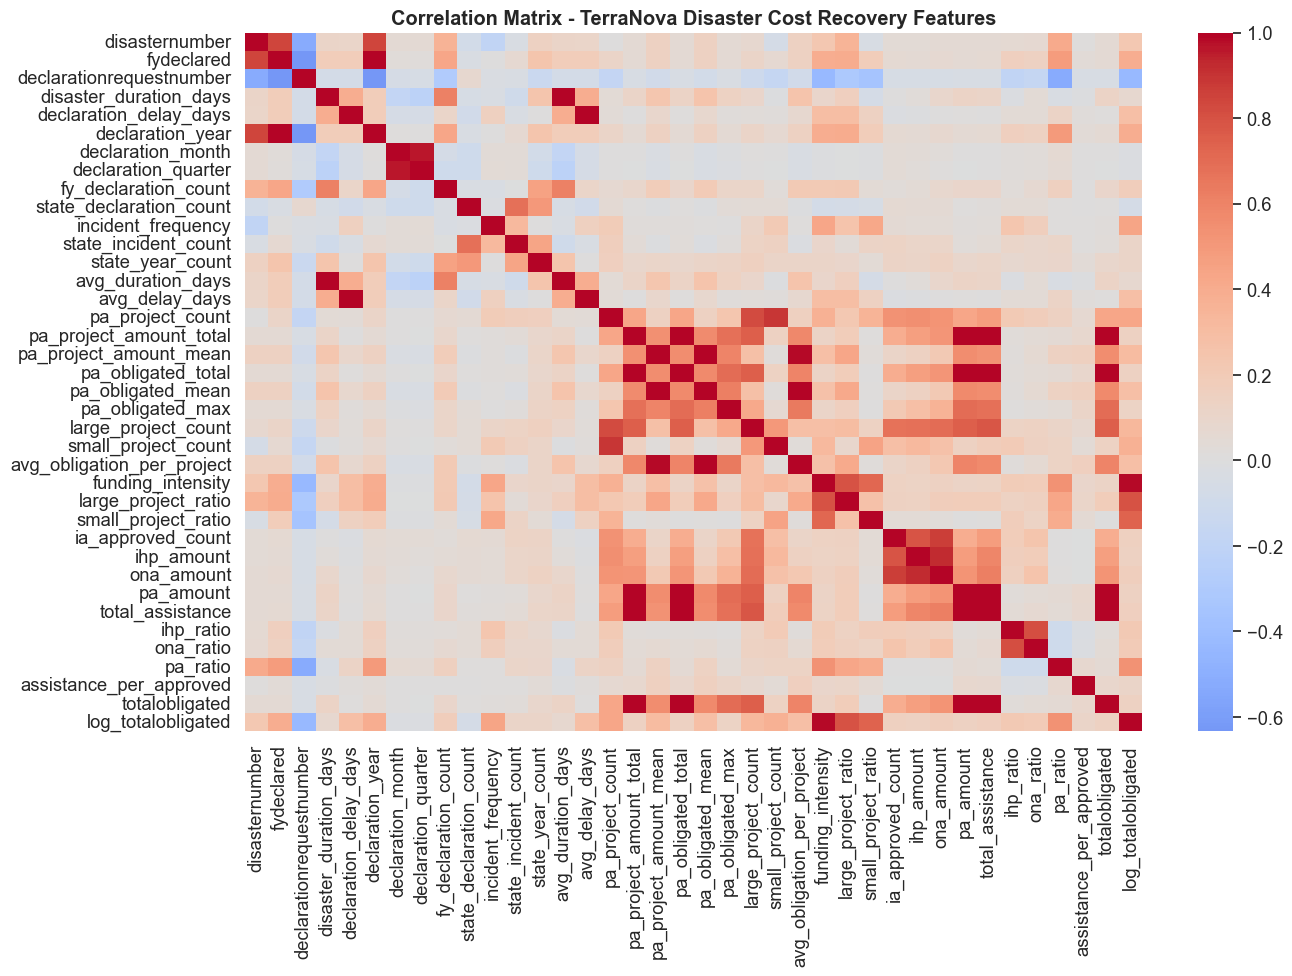

In [20]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    features_terranova.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - TerraNova Disaster Cost Recovery Features", fontweight="bold")
plt.tight_layout()
plt.show()

### STEP 7 - Correlation Signal Check With Target


In [21]:
target = "log_totalobligated"

numeric_corr_df = features_terranova.select_dtypes(
    include=["int64", "float64", "bool"]
)

corr = (
    numeric_corr_df
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

corr.head(20)

funding_intensity             0.985296
large_project_ratio           0.801238
small_project_ratio           0.732863
pa_ratio                      0.530681
incident_frequency            0.439128
declarationrequestnumber     -0.430243
pa_project_count              0.427602
fydeclared                    0.394355
small_project_count           0.369019
large_project_count           0.335670
pa_project_amount_mean        0.306842
avg_obligation_per_project    0.290355
pa_obligated_mean             0.289490
declaration_delay_days        0.285410
avg_delay_days                0.285410
disasternumber                0.226218
ihp_ratio                     0.211232
ona_ratio                     0.198898
fy_declaration_count          0.173235
ona_amount                    0.169621
Name: log_totalobligated, dtype: float64

### STEP 8 - Plot Top 20 Numeric Correlations with Recovery Cost


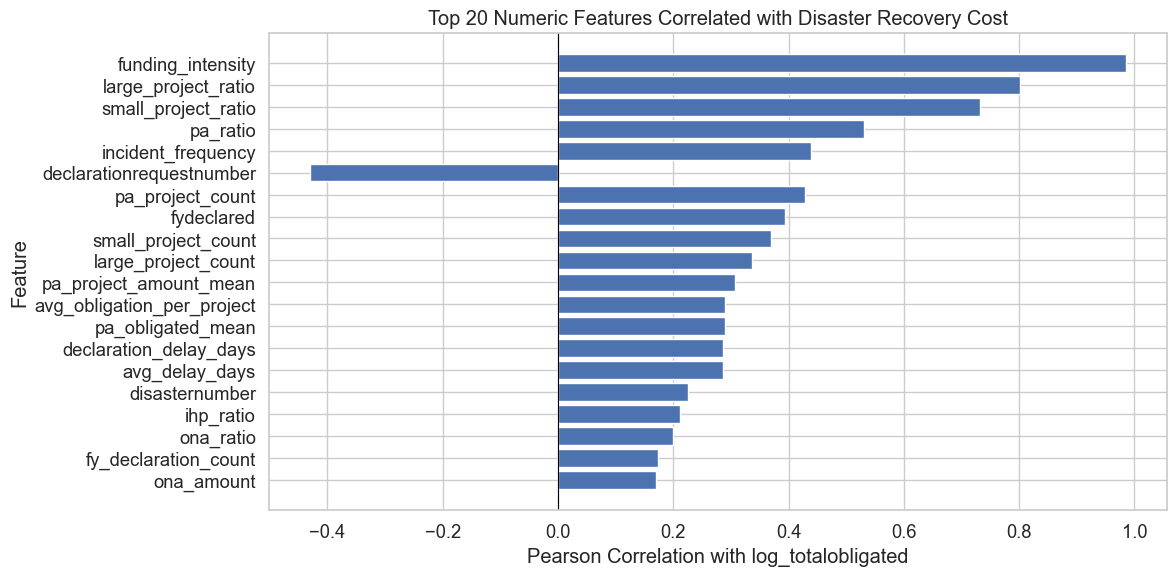

In [22]:

top20 = corr.head(20)

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top20.index[::-1], top20.values[::-1])
ax.axvline(0, color="black", linewidth=0.8)

ax.set(
    title="Top 20 Numeric Features Correlated with Disaster Recovery Cost",
    xlabel="Pearson Correlation with log_totalobligated",
    ylabel="Feature"
)

plt.tight_layout()
plt.show()

### STEP 9 -  Save Final Feature Matrix


In [25]:
features_terranova.to_csv(
    os.path.join(DATA_PROCESSED, "features_terranova.csv"),
    index=False
)

print("Feature matrix saved successfully.")
print("Saved as: features_terranova.csv")
print(features_terranova.shape)

features_terranova.head()

Feature matrix saved successfully.
Saved as: features_terranova.csv
(5184, 43)


,disasternumber,state,declarationtype,incidenttype,fydeclared,designatedarea,declarationrequestnumber,disaster_duration_days,declaration_delay_days,declaration_year,...,ihp_amount,ona_amount,pa_amount,total_assistance,ihp_ratio,ona_ratio,pa_ratio,assistance_per_approved,totalobligated,log_totalobligated
0,3610,PR,EM,Severe Storm,2024,Adjuntas (Municipio),24124,3.0,0,2024,...,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.00,0.00,0.000000
1,5529,OR,FM,Fire,2024,Washington (County),24122,0.0,1,2024,...,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.00,0.00,0.000000
2,5528,OR,FM,Fire,2024,Jefferson (County),24116,0.0,2,2024,...,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.00,0.00,0.000000
3,5527,OR,FM,Fire,2024,Deschutes (County),24111,0.0,0,2024,...,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.00,0.00,0.000000
4,4312,CA,DR,Severe Storm,2017,Resighini Rancheria (Indian Reservation),17035,3.0,83,2017,...,0.0,0.0,269934.77,269934.77,0.0,0.0,0.999996,269934.77,269934.77,12.505939
